In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.model_selection import (train_test_split, KFold,
                                     cross_val_score, GridSearchCV)
from sklearn.linear_model import Lasso, ElasticNet, Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)


In [2]:
df = pd.read_csv('../data/health_index.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(5)


Shape: (470, 16)
Columns: ['Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO', 'CO2', 'Ethylene', 'Ethane', 'Acethylene', 'DBDS', 'Power factor', 'Interfacial V', 'Dielectric rigidity', 'Water content', 'Health index', 'Life expectation']


,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0


In [3]:
df.describe().T.style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
Hydrogen,470.000000,404.261702,2002.142678,0.000000,4.000000,9.000000,34.000000,23349.000000
Oxigen,470.000000,8357.372340,14164.233283,57.000000,496.000000,3810.000000,14875.000000,249900.000000
Nitrogen,470.000000,47759.561702,13760.451816,3600.000000,41700.000000,49100.000000,55875.000000,85300.000000
Methane,470.000000,79.695745,489.320336,0.000000,2.000000,3.000000,7.000000,7406.000000
CO,470.000000,244.000000,237.267485,10.000000,66.000000,150.500000,361.750000,1730.000000
CO2,470.000000,1816.414894,2256.790519,48.000000,641.750000,1125.000000,2257.500000,24900.000000
Ethylene,470.000000,162.923404,1323.811504,0.000000,0.000000,3.000000,6.000000,16684.000000
Ethane,470.000000,81.940426,342.573636,0.000000,0.000000,4.000000,69.750000,5467.000000
Acethylene,470.000000,91.491489,644.365828,0.000000,0.000000,0.000000,0.000000,9740.000000
DBDS,470.000000,17.036596,46.735057,0.000000,0.000000,0.000000,2.000000,227.000000


## 2. Preprocessing

### Steps
1. **IQR Winsorisation** — caps extreme values in all base features at Q1 − 1.5×IQR / Q3 + 1.5×IQR  
2. **Log1p Transform** — applied to dissolved-gas columns (Hydrogen, O₂, N₂, CH₄, CO, CO₂, C₂H₄, C₂H₆, C₂H₂) which are heavily right-skewed  
3. **RobustScaler** — scales using median/IQR, robust to residual outliers  


In [4]:
BASE_FEATURES = [
    'Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO', 'CO2',
    'Ethylene', 'Ethane', 'Acethylene',
    'DBDS', 'Power factor', 'Interfacial V',
    'Dielectric rigidity', 'Water content'
]
GAS_COLS = ['Hydrogen','Oxigen','Nitrogen','Methane','CO','CO2',
            'Ethylene','Ethane','Acethylene']

# Step 1 — IQR Winsorisation
df_clean = df.copy()
for col in BASE_FEATURES:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Step 2 — Log1p on gas features
df_proc = df_clean.copy()
for col in GAS_COLS:
    df_proc[col] = np.log1p(df_proc[col].clip(lower=0))

print(f"Rows retained: {len(df_proc)} / {len(df)} (winsorisation keeps all rows)")
df_proc[BASE_FEATURES].describe().T[['mean','std','min','max']]


Rows retained: 470 / 470 (winsorisation keeps all rows)


,mean,std,min,max
Hydrogen,2.376608,1.383870,0.000000,4.382027
Oxigen,7.955413,1.691841,4.060443,10.503546
Nitrogen,10.736675,0.310841,9.925176,11.253358
Methane,1.465154,0.889799,0.000000,2.740840
CO,5.012651,1.023700,2.397895,6.692549
CO2,7.073768,0.826416,3.891820,8.451507
Ethylene,1.087542,1.078596,0.000000,2.772589
Ethane,2.062268,2.080205,0.000000,5.166927
Acethylene,0.000000,0.000000,0.000000,0.000000
DBDS,1.322128,2.096189,0.000000,5.000000


### Distribution of features after preprocessing

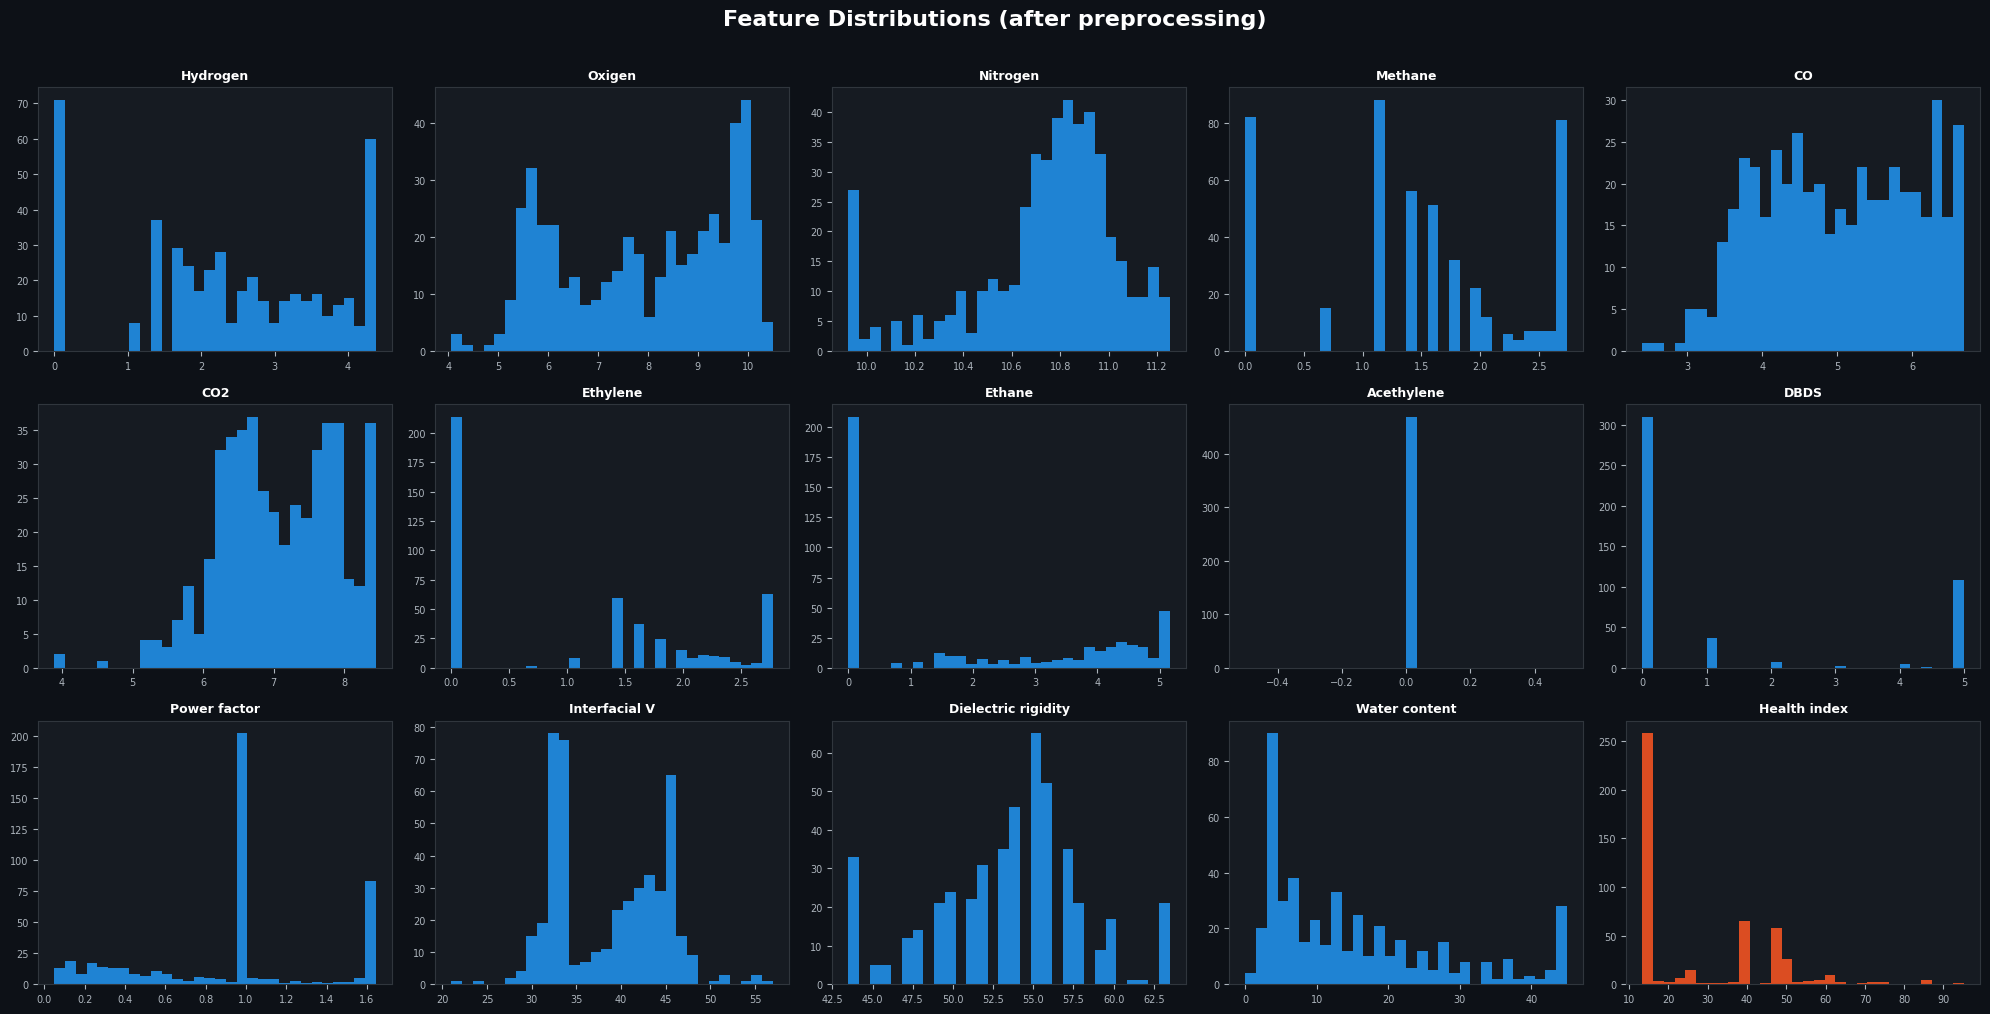

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10), facecolor='#0d1117')
fig.suptitle('Feature Distributions (after preprocessing)', fontsize=16,
             color='white', fontweight='bold', y=1.01)

all_cols = BASE_FEATURES + ['Health index', 'Life expectation']
for ax, col in zip(axes.flat, all_cols):
    ax.set_facecolor('#161b22')
    color = '#2196F3' if col not in ['Health index','Life expectation'] else '#FF5722'
    ax.hist(df_proc[col], bins=30, color=color, edgecolor='none', alpha=0.85)
    ax.set_title(col, color='white', fontsize=9, fontweight='bold')
    ax.tick_params(colors='#adb5bd', labelsize=7)
    for spine in ax.spines.values(): spine.set_color('#30363d')

for ax in axes.flat[len(all_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### Correlation Heatmap

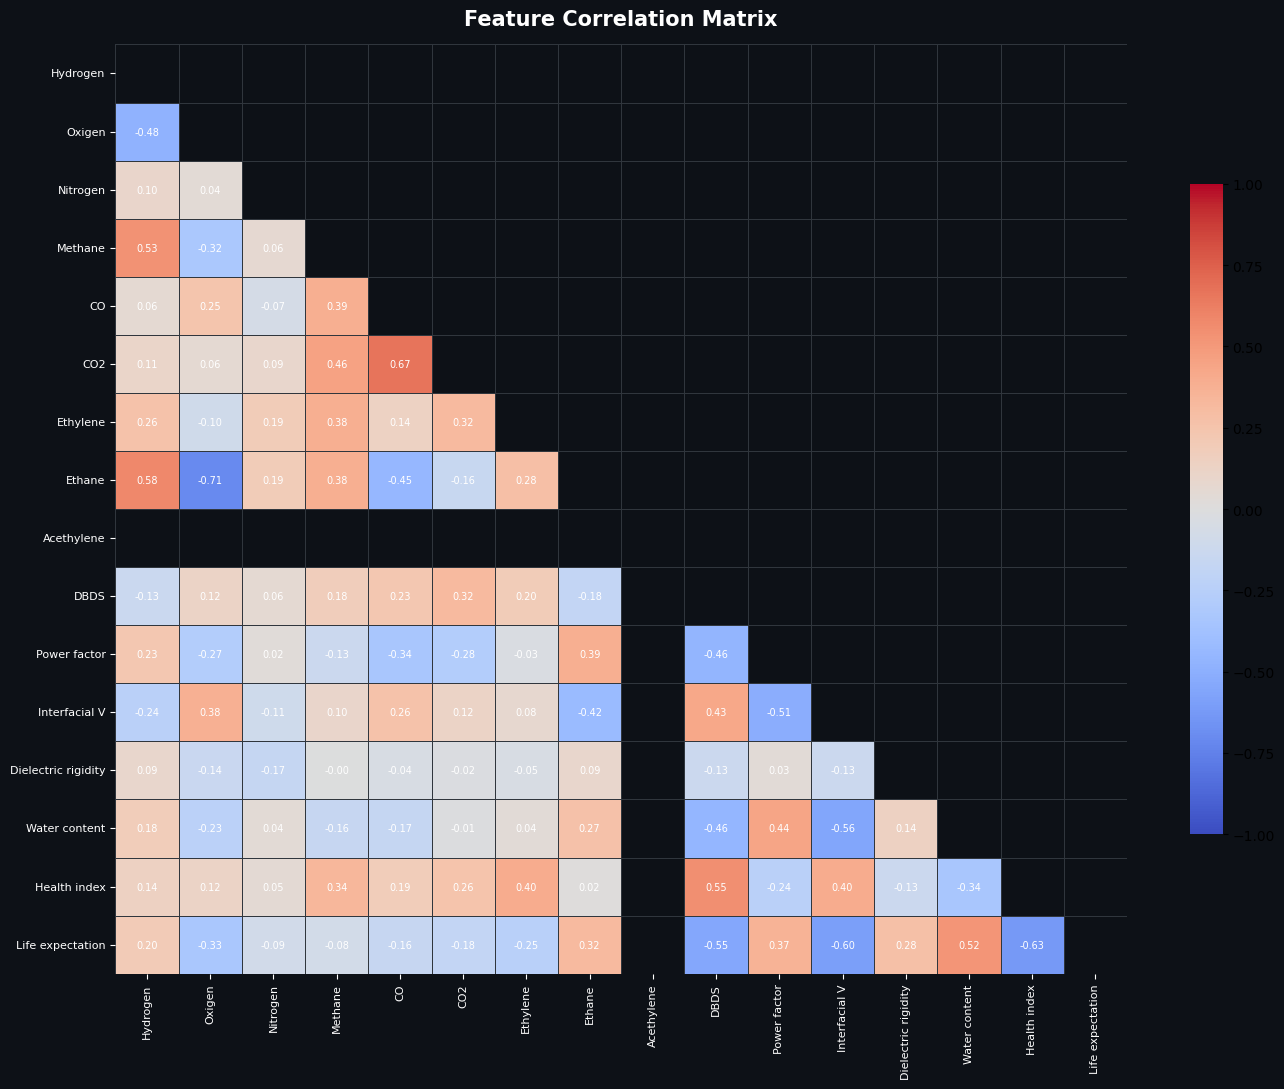

In [6]:
fig, ax = plt.subplots(figsize=(14, 11), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

corr = df_proc[BASE_FEATURES + ['Health index', 'Life expectation']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            annot_kws={'size': 7, 'color': 'white'},
            linewidths=0.4, linecolor='#30363d',
            cbar_kws={'shrink': 0.7}, ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=15, color='white',
             fontweight='bold', pad=14)
ax.tick_params(colors='white', labelsize=8)
plt.tight_layout()
plt.show()


## 3. Build & Train Models

### Architecture
Four models are trained per target:
- **Linear Regression** (baseline) — no regularisation
- **Ridge (L2)** — shrinks all coefficients uniformly; α tuned via GridSearchCV
- **Lasso (L1)** — sparsity-inducing; α tuned via GridSearchCV
- **Elastic Net (L1+L2)** — combines sparsity and ridge shrinkage; α & l1_ratio tuned

Pipeline: `RobustScaler → PolynomialFeatures(degree=2) → RobustScaler → regressor`


In [7]:
# ── Dataset splits ───────────────────────────────────────────
X1_raw = df_proc[BASE_FEATURES + ['Life expectation']].values
y1     = df_proc['Health index'].values

X2_raw = df_proc[BASE_FEATURES + ['Health index']].values
y2     = df_proc['Life expectation'].values

scaler1 = RobustScaler()
X1 = scaler1.fit_transform(X1_raw)
scaler2 = RobustScaler()
X2 = scaler2.fit_transform(X2_raw)

X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f"Model 1 — Train: {len(X1_tr)}, Test: {len(X1_te)}")
print(f"Model 2 — Train: {len(X2_tr)}, Test: {len(X2_te)}")


Model 1 — Train: 376, Test: 94
Model 2 — Train: 376, Test: 94


In [8]:
alpha_grid = {'reg__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}
en_grid    = {'reg__alpha':    [0.001, 0.01, 0.1, 0.5, 1.0],
               'reg__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def build_pipe(regressor, interaction_only=False):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False,
                                    interaction_only=interaction_only)),
        ('sc',   RobustScaler()),
        ('reg',  regressor)
    ])

lr1 = build_pipe(LinearRegression(), interaction_only=False)
lr1.fit(X1_tr, y1_tr)

gs1_ridge = GridSearchCV(build_pipe(Ridge(), interaction_only=False),
                         alpha_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
gs1_ridge.fit(X1_tr, y1_tr)
print(f"M1 Ridge best α = {gs1_ridge.best_params_['reg__alpha']}")

gs1_lasso = GridSearchCV(build_pipe(Lasso(max_iter=100_000), interaction_only=False),
                         alpha_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
gs1_lasso.fit(X1_tr, y1_tr)
print(f"M1 Lasso best α = {gs1_lasso.best_params_['reg__alpha']}")

gs1_en = GridSearchCV(build_pipe(ElasticNet(max_iter=100_000), interaction_only=False),
                      en_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
gs1_en.fit(X1_tr, y1_tr)
print(f"M1 ElasticNet best params: {gs1_en.best_params_}")

lr2 = build_pipe(LinearRegression(), interaction_only=True)
lr2.fit(X2_tr, y2_tr)

gs2_ridge = GridSearchCV(build_pipe(Ridge(), interaction_only=True),
                         alpha_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
gs2_ridge.fit(X2_tr, y2_tr)
print(f"M2 Ridge best α = {gs2_ridge.best_params_['reg__alpha']}")

gs2_lasso = GridSearchCV(build_pipe(Lasso(max_iter=100_000), interaction_only=True),
                         alpha_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
gs2_lasso.fit(X2_tr, y2_tr)
print(f"M2 Lasso best α = {gs2_lasso.best_params_['reg__alpha']}")

gs2_en = GridSearchCV(build_pipe(ElasticNet(max_iter=100_000), interaction_only=True),
                      en_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
gs2_en.fit(X2_tr, y2_tr)
print(f"M2 ElasticNet best params: {gs2_en.best_params_}")


M1 Ridge best α = 1.0
M1 Lasso best α = 0.1
M1 ElasticNet best params: {'reg__alpha': 0.1, 'reg__l1_ratio': 0.9}
M2 Ridge best α = 1.0
M2 Lasso best α = 0.1
M2 ElasticNet best params: {'reg__alpha': 0.1, 'reg__l1_ratio': 0.9}


In [9]:
model1_ridge = build_pipe(Ridge(alpha=gs1_ridge.best_params_['reg__alpha']), interaction_only=False)
model1_ridge.fit(X1_tr, y1_tr)

model1_lasso = build_pipe(Lasso(alpha=gs1_lasso.best_params_['reg__alpha'], max_iter=100_000), interaction_only=False)
model1_lasso.fit(X1_tr, y1_tr)

model1_en = build_pipe(ElasticNet(alpha=gs1_en.best_params_['reg__alpha'],
                                   l1_ratio=gs1_en.best_params_['reg__l1_ratio'],
                                   max_iter=100_000), interaction_only=False)
model1_en.fit(X1_tr, y1_tr)

model2_ridge = build_pipe(Ridge(alpha=gs2_ridge.best_params_['reg__alpha']), interaction_only=True)
model2_ridge.fit(X2_tr, y2_tr)

model2_lasso = build_pipe(Lasso(alpha=gs2_lasso.best_params_['reg__alpha'], max_iter=100_000), interaction_only=True)
model2_lasso.fit(X2_tr, y2_tr)

model2_en = build_pipe(ElasticNet(alpha=gs2_en.best_params_['reg__alpha'],
                                   l1_ratio=gs2_en.best_params_['reg__l1_ratio'],
                                   max_iter=100_000), interaction_only=True)
model2_en.fit(X2_tr, y2_tr)

y1_pred_lr    = lr1.predict(X1_te)
y1_pred_ridge = model1_ridge.predict(X1_te)
y1_pred_lasso = model1_lasso.predict(X1_te)
y1_pred_en    = model1_en.predict(X1_te)

y2_pred_lr    = lr2.predict(X2_te)
y2_pred_ridge = model2_ridge.predict(X2_te)
y2_pred_lasso = model2_lasso.predict(X2_te)
y2_pred_en    = model2_en.predict(X2_te)

y1_pred = y1_pred_lasso
y2_pred = y2_pred_lasso
model1  = model1_lasso
model2  = model2_lasso


## 4. Evaluation Metrics

In [10]:
def full_metrics(y_true, y_pred, model, X_full, y_full, cv=5, label=''):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    pearson_r, p_val = sp_stats.pearsonr(y_true, y_pred)
    kf_cv = KFold(n_splits=cv, shuffle=True, random_state=42)
    cv_r2  = cross_val_score(model, X_full, y_full, cv=kf_cv, scoring='r2').mean()
    cv_mae = -cross_val_score(model, X_full, y_full, cv=kf_cv,
                              scoring='neg_mean_absolute_error').mean()
    return dict(Label=label, R2=r2, MAE=mae, RMSE=rmse,
                Pearson_r=pearson_r, Pearson_p=p_val,
                CV_R2=cv_r2, CV_MAE=cv_mae)

m1_lr    = full_metrics(y1_te, y1_pred_lr,    lr1,          X1, y1, label='M1 LinReg')
m1_ridge = full_metrics(y1_te, y1_pred_ridge, model1_ridge, X1, y1, label='M1 Ridge')
m1_lasso = full_metrics(y1_te, y1_pred_lasso, model1_lasso, X1, y1, label='M1 Lasso')
m1_en    = full_metrics(y1_te, y1_pred_en,    model1_en,    X1, y1, label='M1 ElasticNet')

m2_lr    = full_metrics(y2_te, y2_pred_lr,    lr2,          X2, y2, label='M2 LinReg')
m2_ridge = full_metrics(y2_te, y2_pred_ridge, model2_ridge, X2, y2, label='M2 Ridge')
m2_lasso = full_metrics(y2_te, y2_pred_lasso, model2_lasso, X2, y2, label='M2 Lasso')
m2_en    = full_metrics(y2_te, y2_pred_en,    model2_en,    X2, y2, label='M2 ElasticNet')

m1_metrics = m1_lasso
m2_metrics = m2_lasso

summary = pd.DataFrame([m1_lr, m1_ridge, m1_lasso, m1_en,
                         m2_lr, m2_ridge, m2_lasso, m2_en]).set_index('Label')
summary_fmt = summary.copy()
for col in summary_fmt.columns:
    summary_fmt[col] = summary_fmt[col].map('{:.4f}'.format)
summary_fmt


,R2,MAE,RMSE,Pearson_r,Pearson_p,CV_R2,CV_MAE
Label,,,,,,,
M1 LinReg,0.5479,8.2715,12.4436,0.7605,0.0000,0.3851,9.3336
M1 Ridge,0.5827,7.9687,11.9553,0.7781,0.0000,0.4474,8.9350
M1 Lasso,0.6579,7.4429,10.8240,0.8144,0.0000,0.5860,7.7198
M1 ElasticNet,0.6512,7.6372,10.9290,0.8108,0.0000,0.5962,7.6970
M2 LinReg,0.7704,6.3677,8.0790,0.8844,0.0000,0.6120,7.5140
M2 Ridge,0.7761,6.2568,7.9776,0.8855,0.0000,0.6292,7.3930
M2 Lasso,0.7830,5.9441,7.8542,0.8852,0.0000,0.6636,7.2470
M2 ElasticNet,0.7759,6.0871,7.9811,0.8811,0.0000,0.6671,7.3137


In [11]:
styled = summary.style \
    .format('{:.4f}') \
    .background_gradient(subset=['R2','CV_R2','Pearson_r'], cmap='Greens') \
    .background_gradient(subset=['MAE','RMSE','CV_MAE'], cmap='Reds_r') \
    .set_caption('Model Performance — green = better, red = better for errors') \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold')]
    }])
styled


,R2,MAE,RMSE,Pearson_r,Pearson_p,CV_R2,CV_MAE
Label,,,,,,,
M1 LinReg,0.5479,8.2715,12.4436,0.7605,0.0000,0.3851,9.3336
M1 Ridge,0.5827,7.9687,11.9553,0.7781,0.0000,0.4474,8.9350
M1 Lasso,0.6579,7.4429,10.8240,0.8144,0.0000,0.5860,7.7198
M1 ElasticNet,0.6512,7.6372,10.9290,0.8108,0.0000,0.5962,7.6970
M2 LinReg,0.7704,6.3677,8.0790,0.8844,0.0000,0.6120,7.5140
M2 Ridge,0.7761,6.2568,7.9776,0.8855,0.0000,0.6292,7.3930
M2 Lasso,0.7830,5.9441,7.8542,0.8852,0.0000,0.6636,7.2470
M2 ElasticNet,0.7759,6.0871,7.9811,0.8811,0.0000,0.6671,7.3137


## 5. Pearson Correlation — Predicted vs Actual

Pearson r measures the **linear correlation** between actual and predicted values.  
A value close to **+1.0** means the model ranks samples almost perfectly.


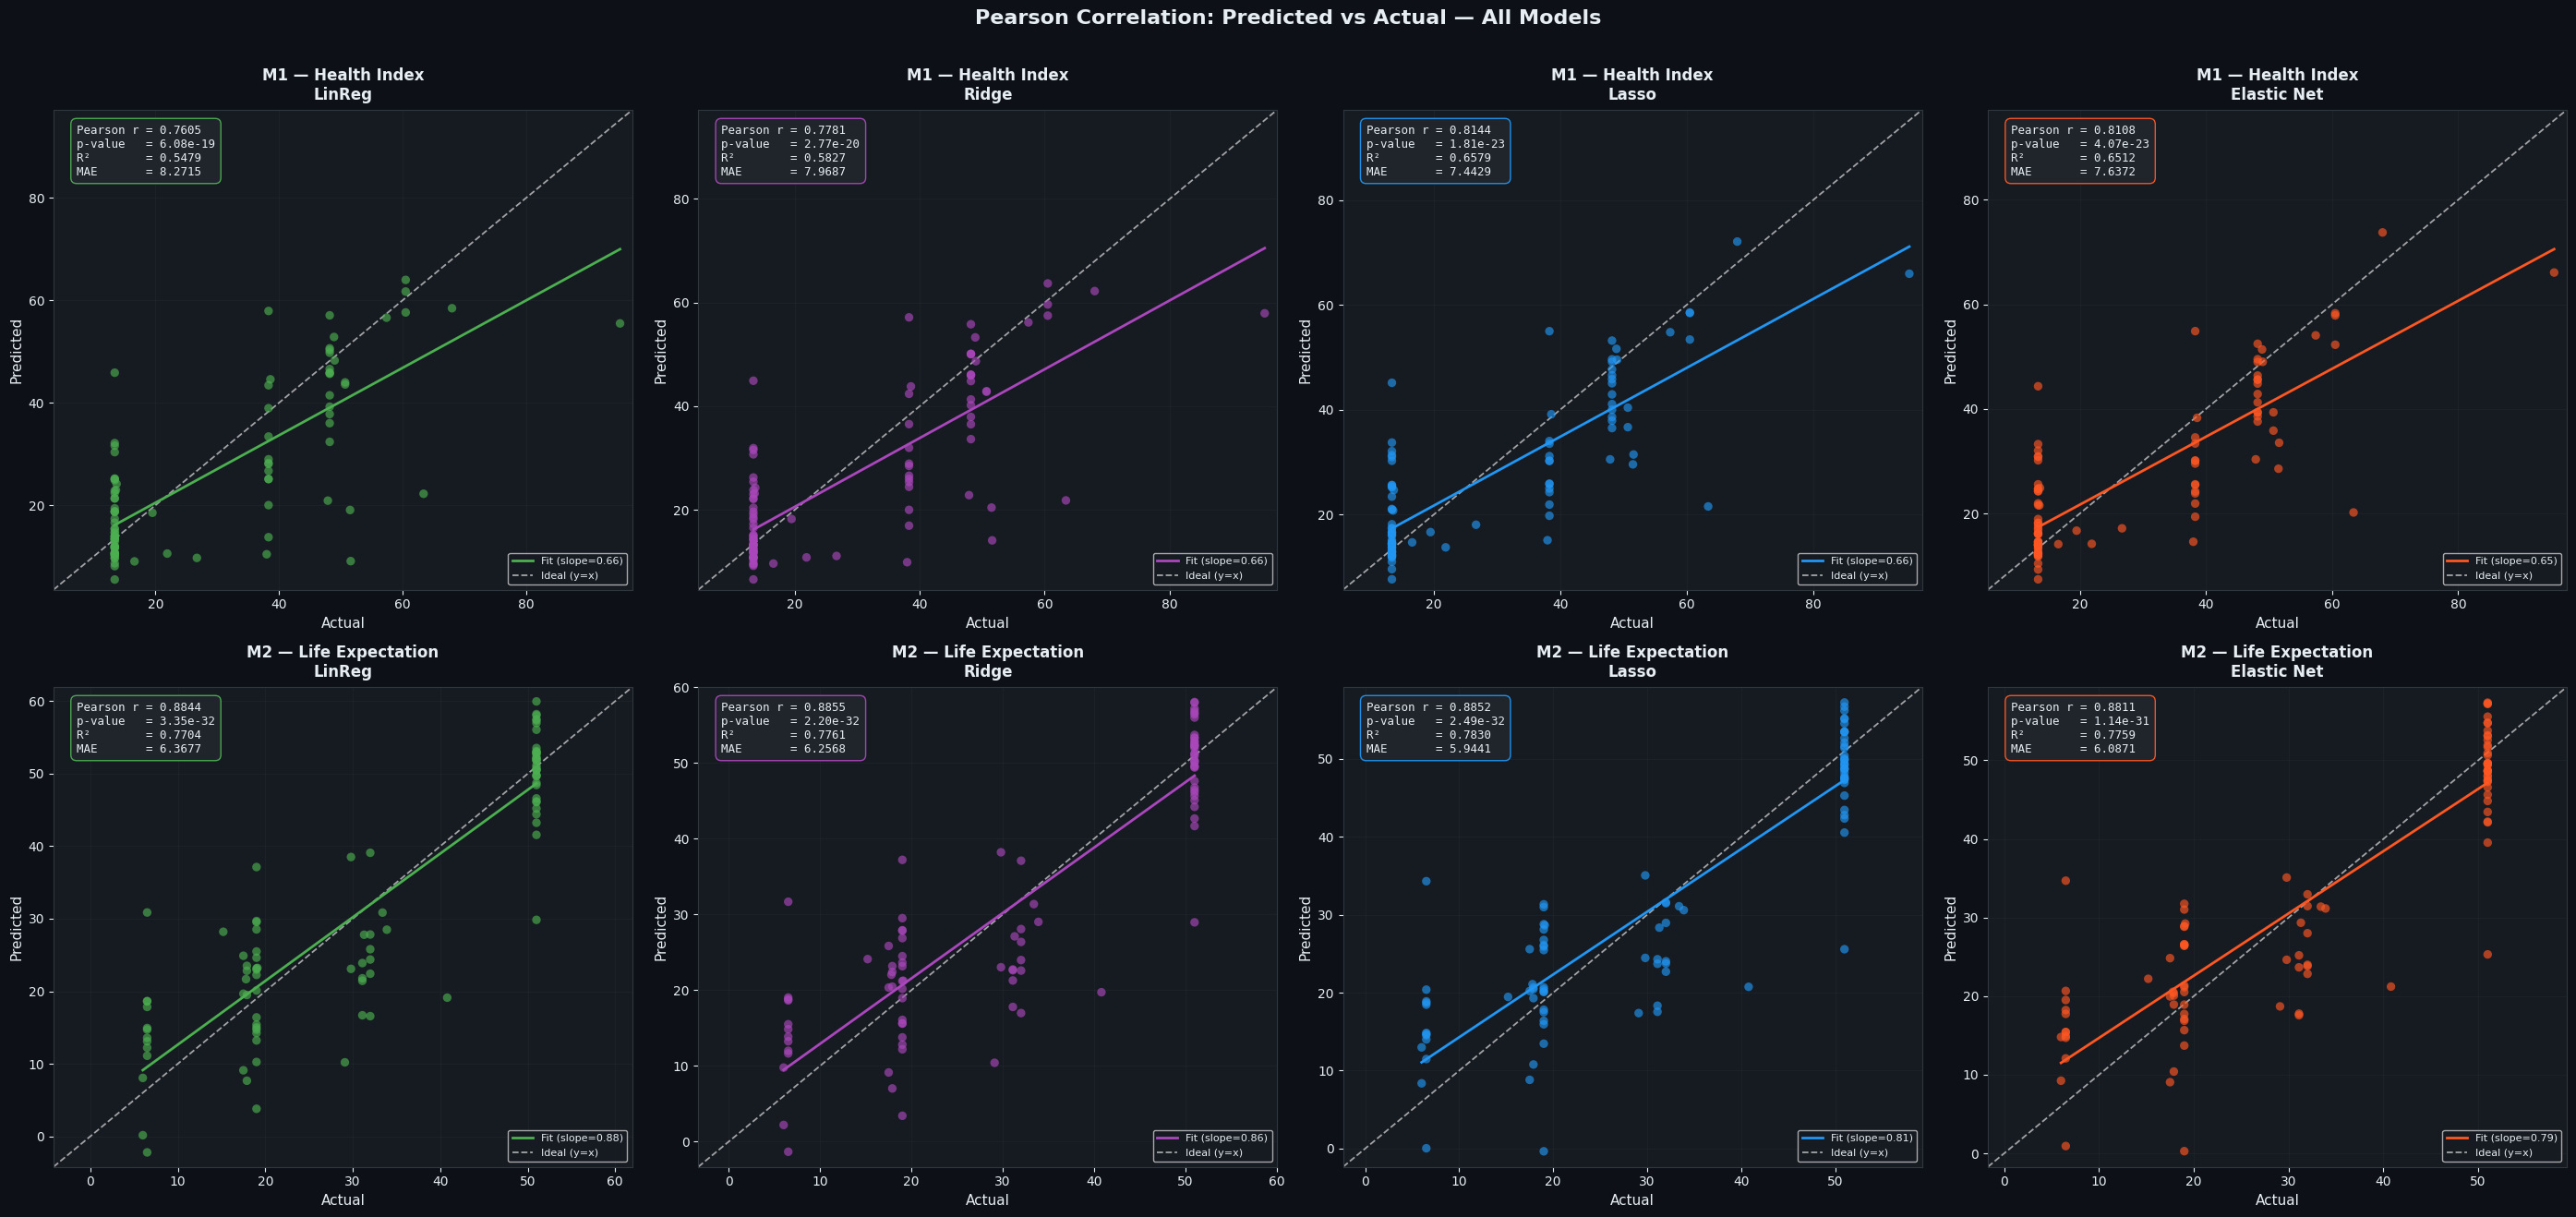

Saved → pearson_correlation.png


In [12]:
BG, CARD, TEXT, GRID = '#0d1117', '#161b22', '#e6edf3', '#30363d'
C1, C2, C3, C4 = '#2196F3', '#FF5722', '#4CAF50', '#AB47BC'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'grid.color': GRID,
    'font.family': 'DejaVu Sans',
})

fig, axes = plt.subplots(2, 4, figsize=(28, 13), facecolor=BG)

panels = [
    (axes[0,0], y1_te, y1_pred_lr,    C3, 'M1 — Health Index\nLinReg',      m1_lr),
    (axes[0,1], y1_te, y1_pred_ridge, C4, 'M1 — Health Index\nRidge',       m1_ridge),
    (axes[0,2], y1_te, y1_pred_lasso, C1, 'M1 — Health Index\nLasso',       m1_lasso),
    (axes[0,3], y1_te, y1_pred_en,    C2, 'M1 — Health Index\nElastic Net', m1_en),
    (axes[1,0], y2_te, y2_pred_lr,    C3, 'M2 — Life Expectation\nLinReg',      m2_lr),
    (axes[1,1], y2_te, y2_pred_ridge, C4, 'M2 — Life Expectation\nRidge',       m2_ridge),
    (axes[1,2], y2_te, y2_pred_lasso, C1, 'M2 — Life Expectation\nLasso',       m2_lasso),
    (axes[1,3], y2_te, y2_pred_en,    C2, 'M2 — Life Expectation\nElastic Net', m2_en),
]

for ax, yt, yp, c, title, mets in panels:
    ax.scatter(yt, yp, alpha=0.65, color=c, s=45, edgecolors='none', zorder=3)
    m_fit, b_fit = np.polyfit(yt, yp, 1)
    x_line = np.linspace(yt.min(), yt.max(), 200)
    ax.plot(x_line, m_fit*x_line + b_fit, color=c, lw=2.0,
            label=f'Fit (slope={m_fit:.2f})', zorder=4)
    lo, hi = min(yt.min(), yp.min())-2, max(yt.max(), yp.max())+2
    ax.plot([lo,hi],[lo,hi], '--', color='white', lw=1.3, alpha=0.6, label='Ideal (y=x)')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    box_txt = (f'Pearson r = {mets["Pearson_r"]:.4f}\n'
               f'p-value   = {mets["Pearson_p"]:.2e}\n'
               f'R²        = {mets["R2"]:.4f}\n'
               f'MAE       = {mets["MAE"]:.4f}')
    ax.text(0.04, 0.97, box_txt, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#21262d',
                      edgecolor=c, alpha=0.95),
            color=TEXT, fontfamily='monospace')

fig.suptitle('Pearson Correlation: Predicted vs Actual — All Models', fontsize=16,
             fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig('pearson_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → pearson_correlation.png')


## 6. Residual Analysis

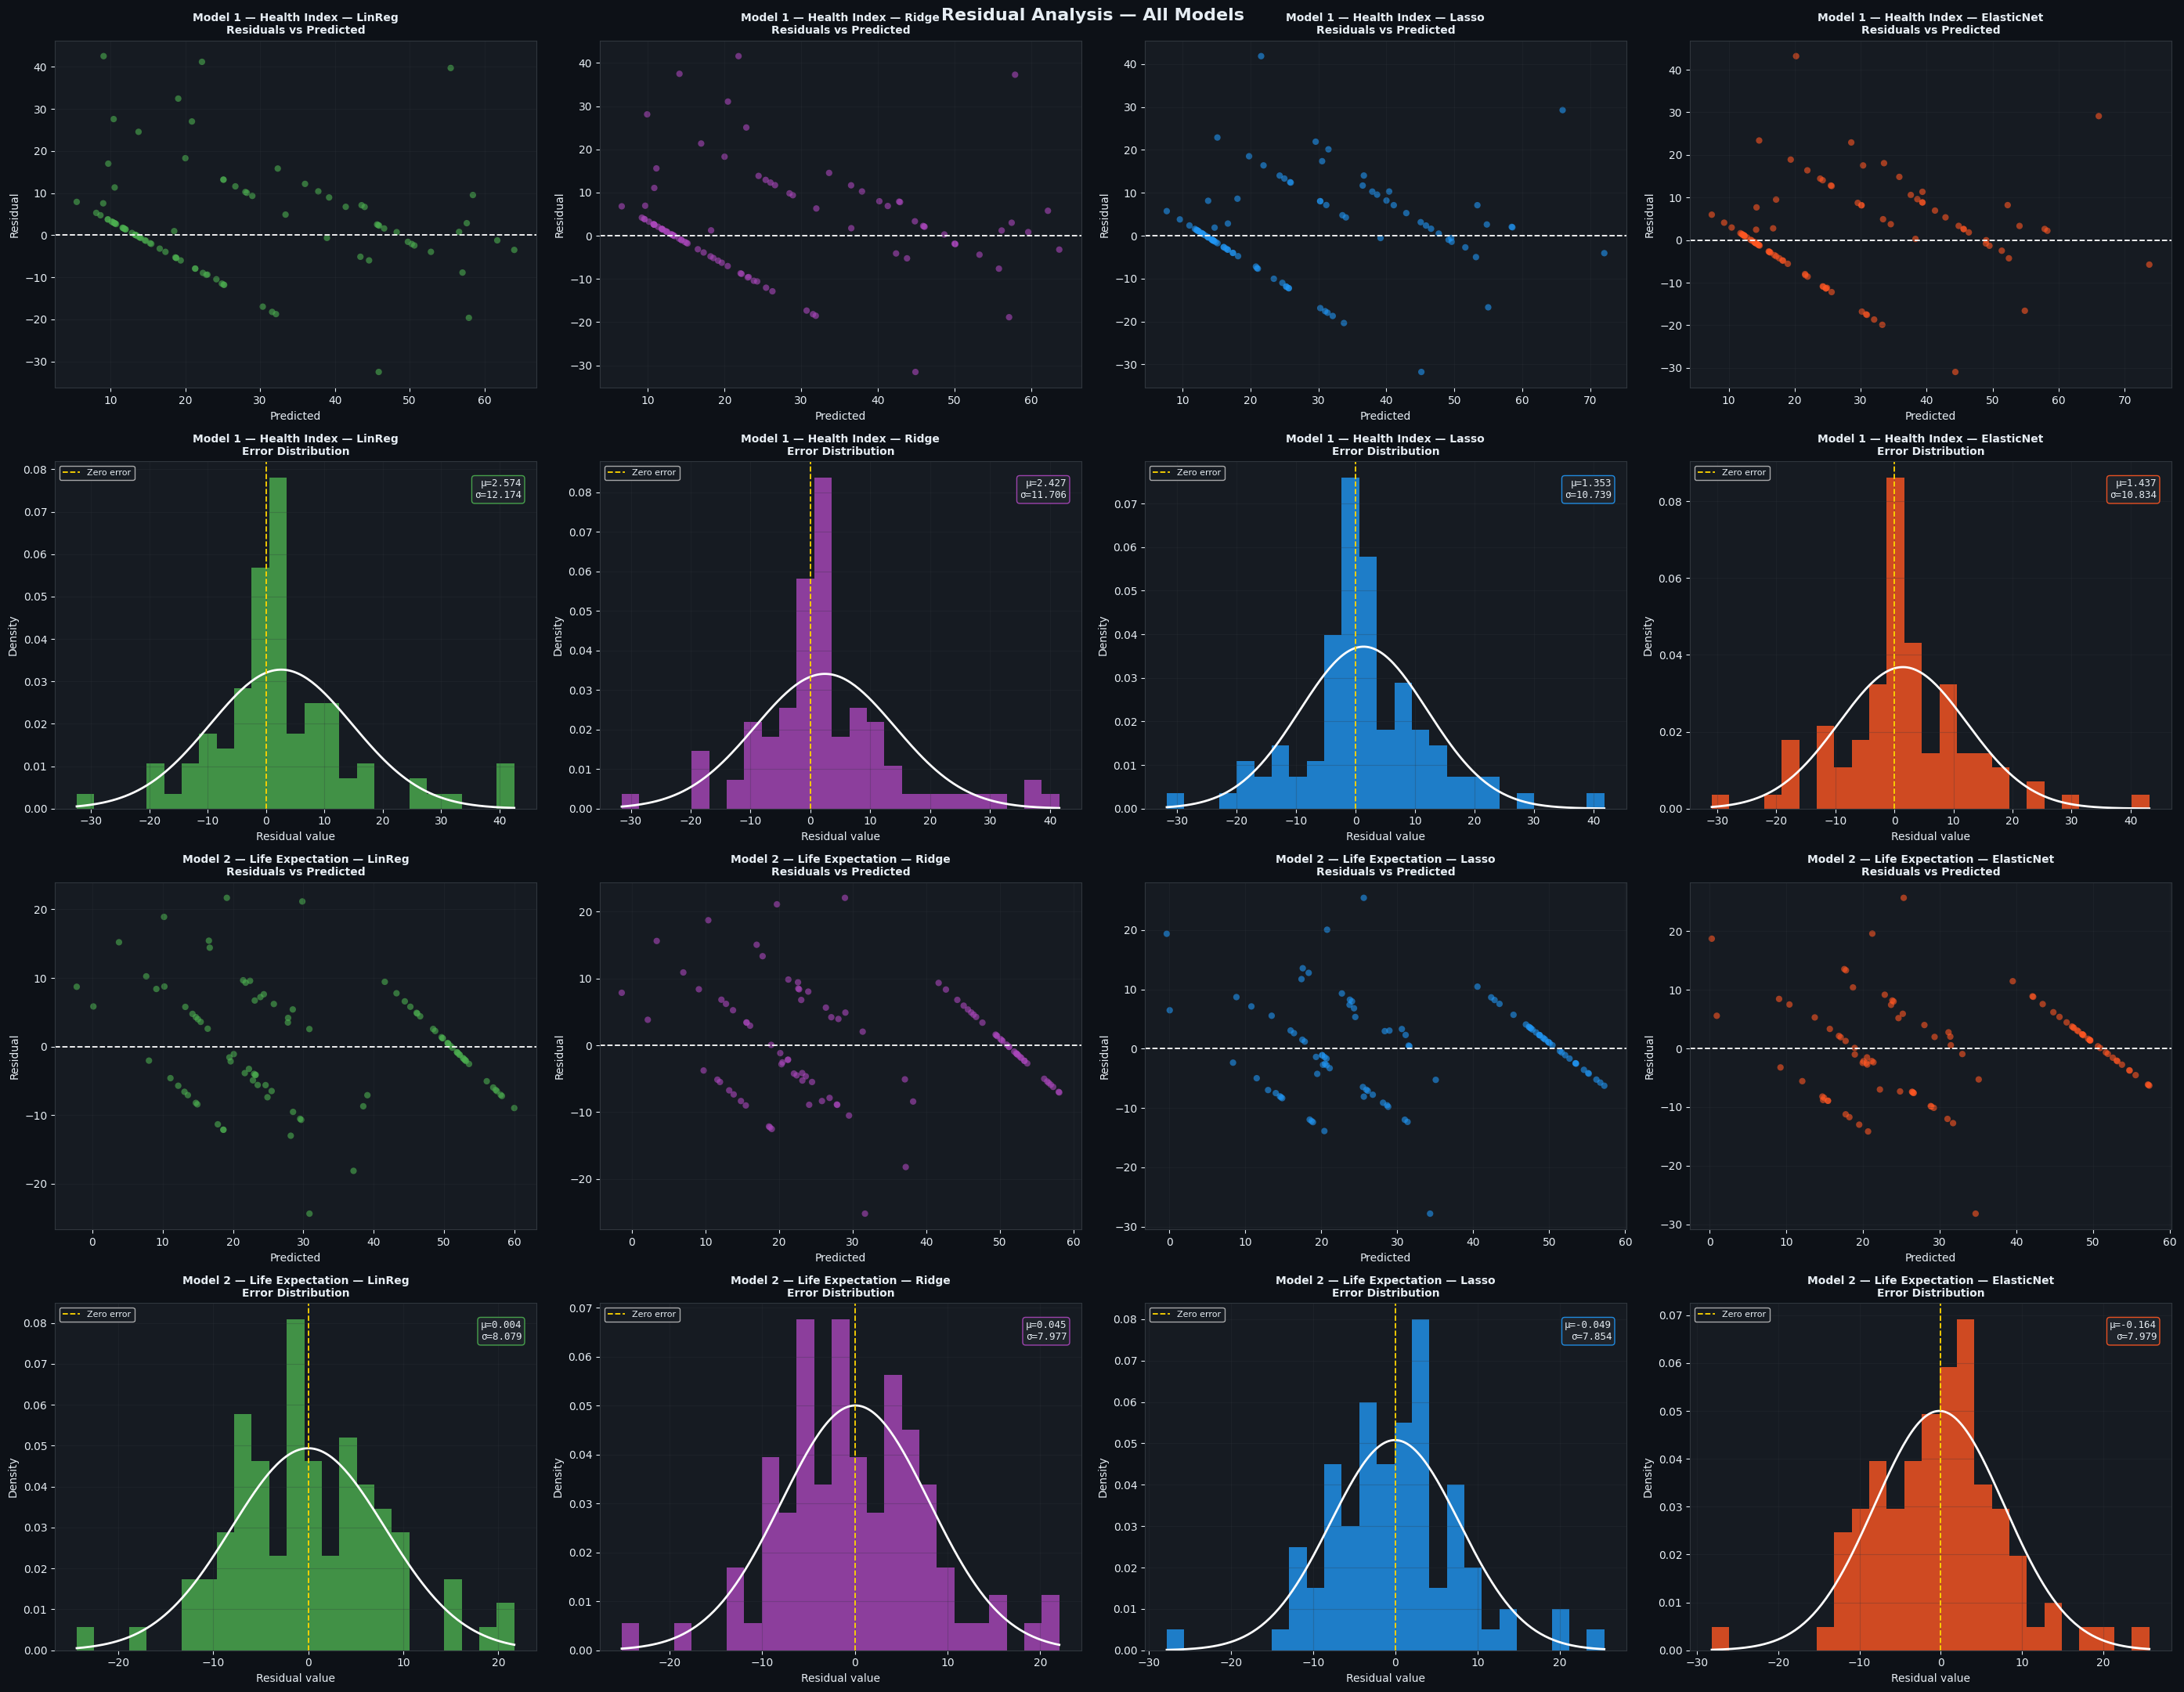

In [13]:
from scipy.stats import norm

fig, axes = plt.subplots(4, 4, figsize=(28, 22), facecolor=BG)

model_rows = [
    (0, 'Model 1 — Health Index', y1_te,
     [('LinReg', y1_pred_lr, C3), ('Ridge', y1_pred_ridge, C4),
      ('Lasso', y1_pred_lasso, C1), ('ElasticNet', y1_pred_en, C2)]),
    (2, 'Model 2 — Life Expectation', y2_te,
     [('LinReg', y2_pred_lr, C3), ('Ridge', y2_pred_ridge, C4),
      ('Lasso', y2_pred_lasso, C1), ('ElasticNet', y2_pred_en, C2)]),
]

for row_off, target_lbl, yt, preds in model_rows:
    for col_idx, (reg_lbl, yp, c) in enumerate(preds):
        resid = yt - yp
        ax_top = axes[row_off, col_idx]
        ax_top.set_facecolor(CARD)
        ax_top.scatter(yp, resid, alpha=0.6, color=c, s=35, edgecolors='none')
        ax_top.axhline(0, color='white', lw=1.3, ls='--')
        ax_top.set_xlabel('Predicted', fontsize=10)
        ax_top.set_ylabel('Residual', fontsize=10)
        ax_top.set_title(f'{target_lbl} — {reg_lbl}\nResiduals vs Predicted',
                         fontsize=10, fontweight='bold', pad=6)
        ax_top.grid(True, alpha=0.25)
        ax_bot = axes[row_off+1, col_idx]
        ax_bot.set_facecolor(CARD)
        ax_bot.hist(resid, bins=25, color=c, alpha=0.8, edgecolor='none', density=True)
        mu, sigma = resid.mean(), resid.std()
        x_norm = np.linspace(resid.min(), resid.max(), 200)
        ax_bot.plot(x_norm, norm.pdf(x_norm, mu, sigma), color='white', lw=2)
        ax_bot.axvline(0, color='#FFD600', lw=1.3, ls='--', label='Zero error')
        ax_bot.set_xlabel('Residual value', fontsize=10)
        ax_bot.set_ylabel('Density', fontsize=10)
        ax_bot.set_title(f'{target_lbl} — {reg_lbl}\nError Distribution',
                         fontsize=10, fontweight='bold', pad=6)
        ax_bot.legend(fontsize=8)
        ax_bot.grid(True, alpha=0.25)
        ax_bot.text(0.97, 0.95, f'μ={mu:.3f}\nσ={sigma:.3f}',
                    transform=ax_bot.transAxes, ha='right', va='top', fontsize=9,
                    color=TEXT, fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#21262d', edgecolor=c, alpha=0.9))

plt.suptitle('Residual Analysis — All Models', fontsize=16, fontweight='bold', color=TEXT)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Feature Coefficients (Top 20)

In [14]:
def get_coefs(model, input_feature_names):
    poly_step  = model.named_steps['poly']
    feat_names = poly_step.get_feature_names_out(input_feature_names)
    coefs      = model.named_steps['reg'].coef_
    return pd.Series(coefs, index=feat_names)

feat1_names = BASE_FEATURES + ['Life expectation']
feat2_names = BASE_FEATURES + ['Health index']

coef_sets = [
    ('M1 LinReg',     get_coefs(lr1,          feat1_names), C3),
    ('M1 Ridge',      get_coefs(model1_ridge, feat1_names), C4),
    ('M1 Lasso',      get_coefs(model1_lasso, feat1_names), C1),
    ('M1 ElasticNet', get_coefs(model1_en,    feat1_names), C2),
    ('M2 LinReg',     get_coefs(lr2,          feat2_names), C3),
    ('M2 Ridge',      get_coefs(model2_ridge, feat2_names), C4),
    ('M2 Lasso',      get_coefs(model2_lasso, feat2_names), C1),
    ('M2 ElasticNet', get_coefs(model2_en,    feat2_names), C2),
]

for lbl, s, _ in coef_sets:
    nz = (s != 0).sum()
    print(f"{lbl}: {nz} non-zero / {len(s)} total coefficients")


M1 LinReg: 133 non-zero / 135 total coefficients
M1 Ridge: 119 non-zero / 135 total coefficients
M1 Lasso: 84 non-zero / 135 total coefficients
M1 ElasticNet: 87 non-zero / 135 total coefficients
M2 LinReg: 119 non-zero / 120 total coefficients
M2 Ridge: 105 non-zero / 120 total coefficients
M2 Lasso: 82 non-zero / 120 total coefficients
M2 ElasticNet: 85 non-zero / 120 total coefficients


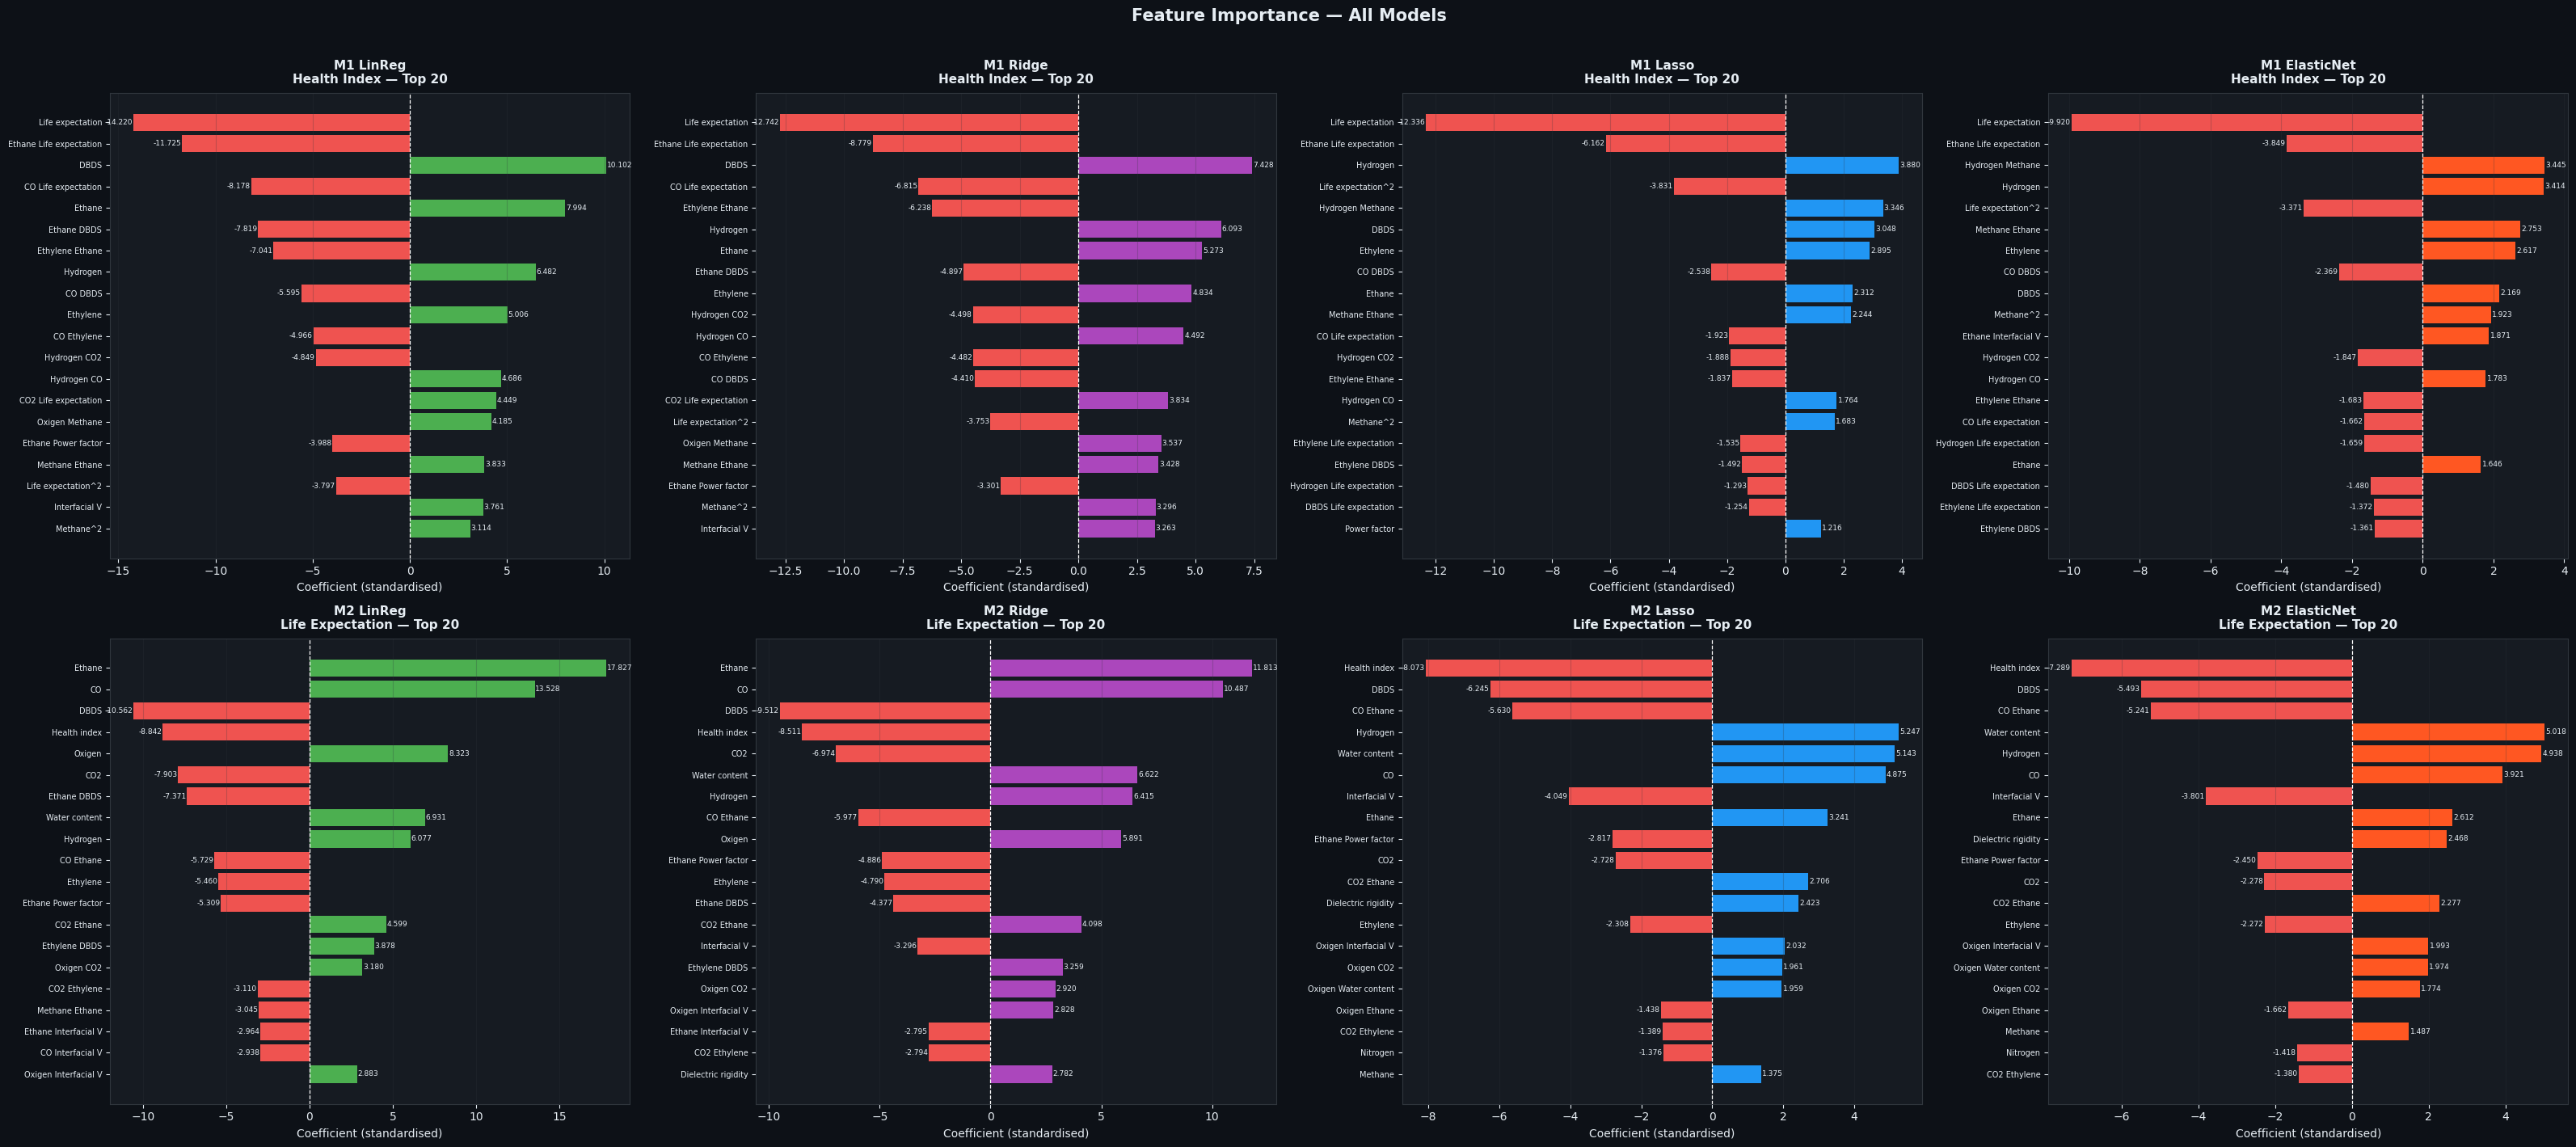

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(32, 14), facecolor=BG)

plot_data = [
    (axes[0,0], get_coefs(lr1,          feat1_names).sort_values(key=abs, ascending=False), C3, 'M1 LinReg\nHealth Index — Top 20'),
    (axes[0,1], get_coefs(model1_ridge, feat1_names).sort_values(key=abs, ascending=False), C4, 'M1 Ridge\nHealth Index — Top 20'),
    (axes[0,2], get_coefs(model1_lasso, feat1_names).sort_values(key=abs, ascending=False), C1, 'M1 Lasso\nHealth Index — Top 20'),
    (axes[0,3], get_coefs(model1_en,    feat1_names).sort_values(key=abs, ascending=False), C2, 'M1 ElasticNet\nHealth Index — Top 20'),
    (axes[1,0], get_coefs(lr2,          feat2_names).sort_values(key=abs, ascending=False), C3, 'M2 LinReg\nLife Expectation — Top 20'),
    (axes[1,1], get_coefs(model2_ridge, feat2_names).sort_values(key=abs, ascending=False), C4, 'M2 Ridge\nLife Expectation — Top 20'),
    (axes[1,2], get_coefs(model2_lasso, feat2_names).sort_values(key=abs, ascending=False), C1, 'M2 Lasso\nLife Expectation — Top 20'),
    (axes[1,3], get_coefs(model2_en,    feat2_names).sort_values(key=abs, ascending=False), C2, 'M2 ElasticNet\nLife Expectation — Top 20'),
]

for ax, coef_series, c, title in plot_data:
    coef = coef_series[coef_series != 0].head(20) if (coef_series != 0).any() else coef_series.head(20)
    ax.set_facecolor(CARD)
    colors = [c if v > 0 else '#EF5350' for v in coef.values[::-1]]
    bars = ax.barh(range(len(coef)), coef.values[::-1], color=colors, edgecolor='none')
    ax.set_yticks(range(len(coef)))
    ax.set_yticklabels(coef.index[::-1], fontsize=7)
    ax.axvline(0, color='white', lw=0.9, ls='--')
    ax.set_xlabel('Coefficient (standardised)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.grid(True, alpha=0.25, axis='x')
    for bar, val in zip(bars, coef.values[::-1]):
        ax.text(val + (0.03 if val >= 0 else -0.03),
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right',
                fontsize=6.5, color=TEXT)

plt.suptitle('Feature Importance — All Models', fontsize=15,
             fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Cross-Validation Scores (5-Fold)

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_scores(model, X, y):
    r2  = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return r2, mae

cv1_lr_r2,    cv1_lr_mae    = cv_scores(lr1,          X1, y1)
cv1_ridge_r2, cv1_ridge_mae = cv_scores(model1_ridge, X1, y1)
cv1_lasso_r2, cv1_lasso_mae = cv_scores(model1_lasso, X1, y1)
cv1_en_r2,    cv1_en_mae    = cv_scores(model1_en,    X1, y1)

cv2_lr_r2,    cv2_lr_mae    = cv_scores(lr2,          X2, y2)
cv2_ridge_r2, cv2_ridge_mae = cv_scores(model2_ridge, X2, y2)
cv2_lasso_r2, cv2_lasso_mae = cv_scores(model2_lasso, X2, y2)
cv2_en_r2,    cv2_en_mae    = cv_scores(model2_en,    X2, y2)

cv1_r2, cv1_mae = cv1_lasso_r2, cv1_lasso_mae
cv2_r2, cv2_mae = cv2_lasso_r2, cv2_lasso_mae

folds = [1,2,3,4,5]
cv_df = pd.DataFrame({
    'Fold':           folds,
    'M1 LR R²':       cv1_lr_r2.round(4),    'M1 LR MAE':    cv1_lr_mae.round(4),
    'M1 Ridge R²':    cv1_ridge_r2.round(4), 'M1 Ridge MAE': cv1_ridge_mae.round(4),
    'M1 Lasso R²':    cv1_lasso_r2.round(4), 'M1 Lasso MAE': cv1_lasso_mae.round(4),
    'M1 EN R²':       cv1_en_r2.round(4),    'M1 EN MAE':    cv1_en_mae.round(4),
    'M2 LR R²':       cv2_lr_r2.round(4),    'M2 LR MAE':    cv2_lr_mae.round(4),
    'M2 Ridge R²':    cv2_ridge_r2.round(4), 'M2 Ridge MAE': cv2_ridge_mae.round(4),
    'M2 Lasso R²':    cv2_lasso_r2.round(4), 'M2 Lasso MAE': cv2_lasso_mae.round(4),
    'M2 EN R²':       cv2_en_r2.round(4),    'M2 EN MAE':    cv2_en_mae.round(4),
})
mean_row = {'Fold': '—'}
for col in cv_df.columns[1:]:
    mean_row[col] = round(cv_df[col].mean(), 4)
cv_df = pd.concat([cv_df, pd.DataFrame([mean_row])], ignore_index=True)

r2_cols  = [c for c in cv_df.columns if 'R²' in c]
mae_cols = [c for c in cv_df.columns if 'MAE' in c]
cv_df.style \
    .background_gradient(subset=r2_cols,  cmap='Greens') \
    .background_gradient(subset=mae_cols, cmap='Reds_r') \
    .set_caption('5-Fold Cross-Validation Scores — All Models')


,Fold,M1 LR R²,M1 LR MAE,M1 Ridge R²,M1 Ridge MAE,M1 Lasso R²,M1 Lasso MAE,M1 EN R²,M1 EN MAE,M2 LR R²,M2 LR MAE,M2 Ridge R²,M2 Ridge MAE,M2 Lasso R²,M2 Lasso MAE,M2 EN R²,M2 EN MAE
0,1,0.547900,8.271500,0.582700,7.968700,0.657900,7.442900,0.651200,7.637200,0.770400,6.367700,0.776100,6.256800,0.783000,5.944100,0.775900,6.087100
1,2,0.460300,9.075500,0.488600,8.878500,0.624800,7.446200,0.633600,7.439000,0.492900,8.760700,0.494400,8.809000,0.533900,9.005500,0.558700,8.924900
2,3,0.366900,9.481100,0.456100,8.867700,0.609900,7.457100,0.613300,7.480300,0.627700,7.452100,0.661700,7.051000,0.723500,6.576100,0.723400,6.613600
3,4,0.413200,9.713800,0.438300,9.509800,0.498700,8.754600,0.497100,8.760000,0.608400,7.615600,0.605400,7.625900,0.593100,7.996600,0.591600,8.176900
4,5,0.137000,10.125900,0.271200,9.450300,0.538500,7.498400,0.585900,7.168700,0.560600,7.374000,0.608400,7.222500,0.684600,6.712800,0.685800,6.765800
5,—,0.385100,9.333600,0.447400,8.935000,0.586000,7.719800,0.596200,7.697000,0.612000,7.514000,0.629200,7.393000,0.663600,7.247000,0.667100,7.313700


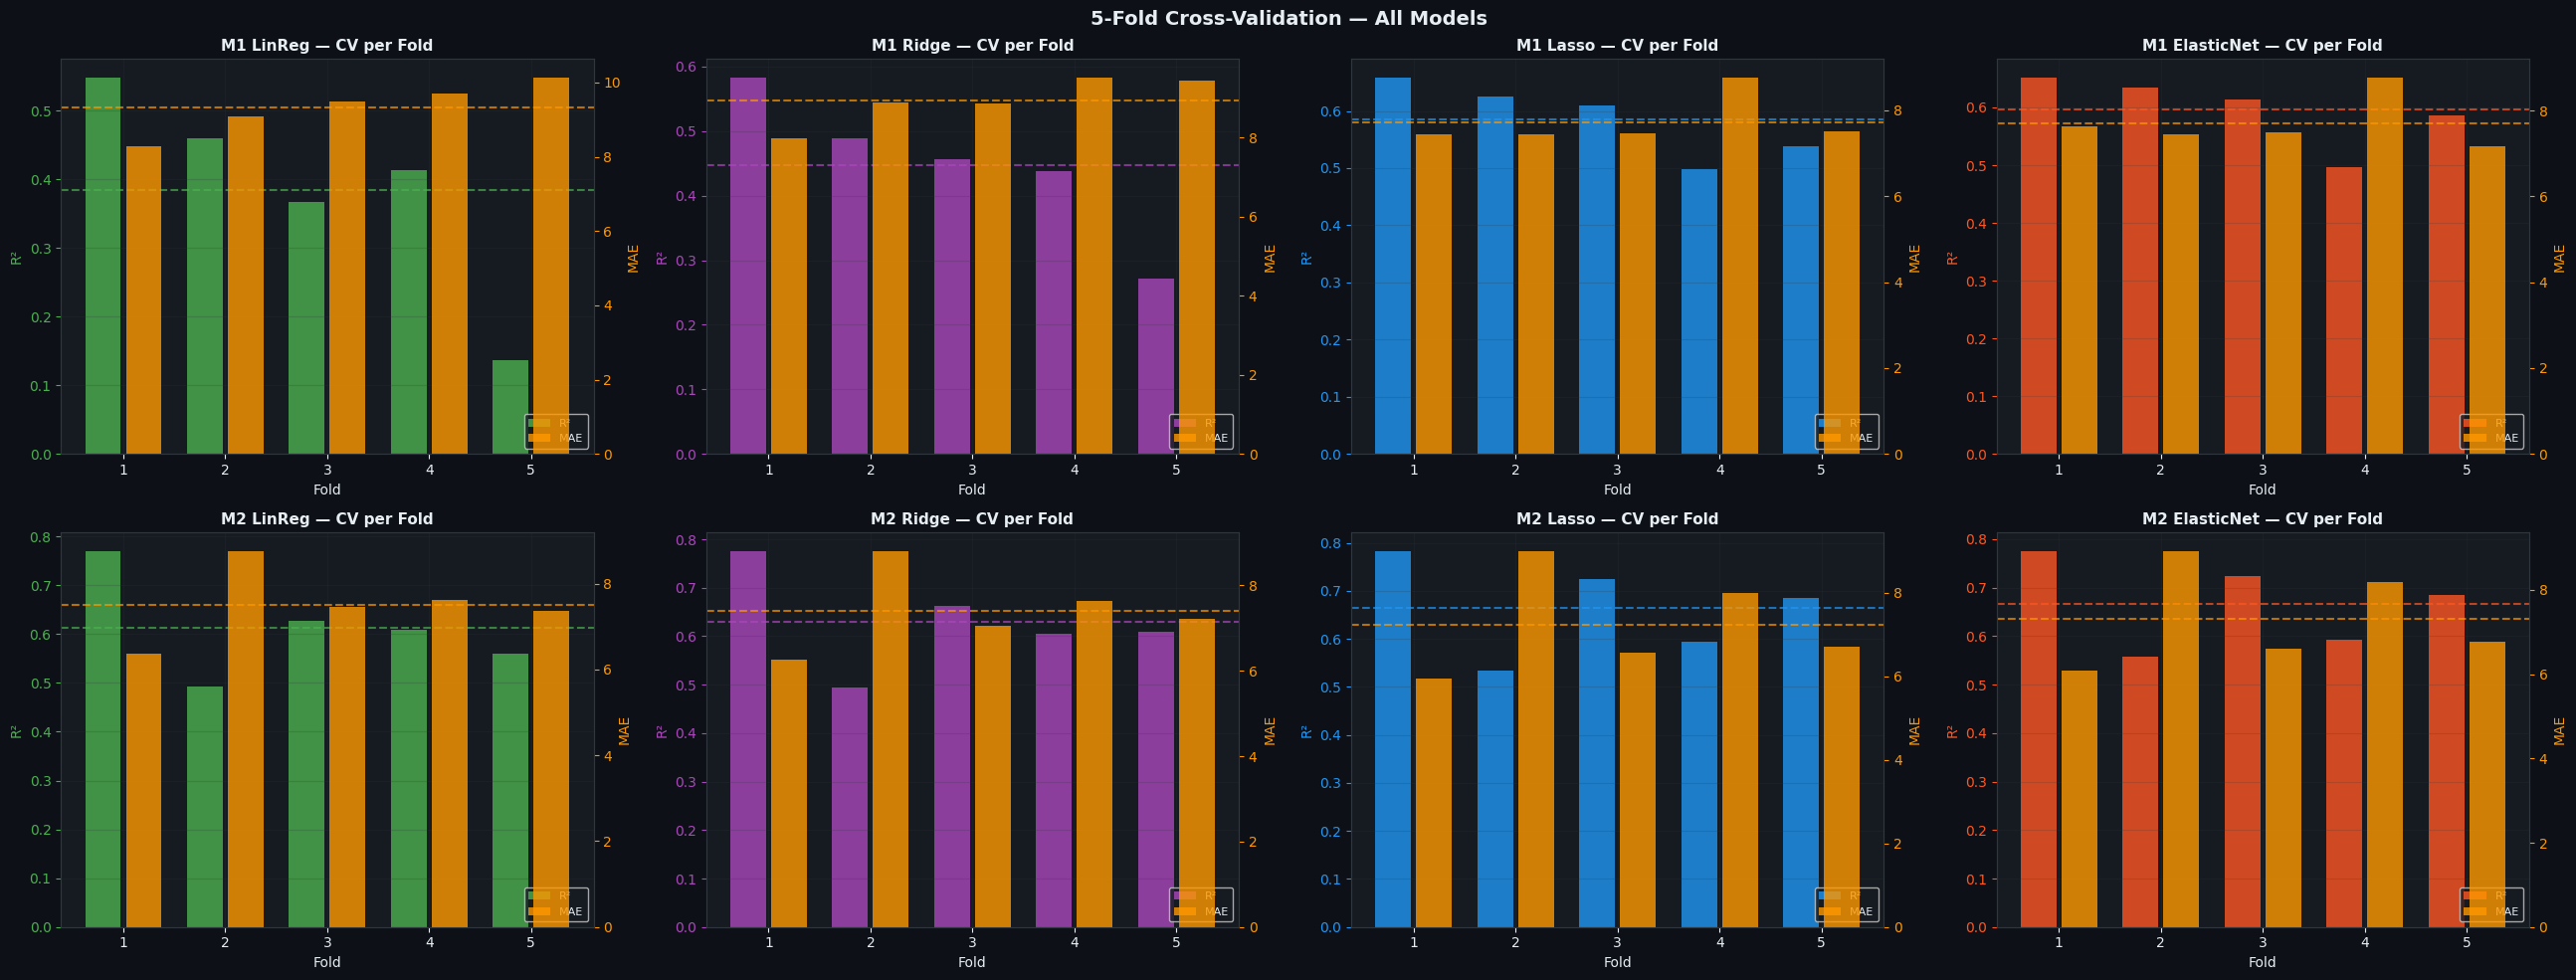

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(26, 10), facecolor=BG)
folds_arr = np.arange(1, 6)

cv_panels = [
    (0, 0, cv1_lr_r2,    cv1_lr_mae,    C3, 'M1 LinReg'),
    (0, 1, cv1_ridge_r2, cv1_ridge_mae, C4, 'M1 Ridge'),
    (0, 2, cv1_lasso_r2, cv1_lasso_mae, C1, 'M1 Lasso'),
    (0, 3, cv1_en_r2,    cv1_en_mae,    C2, 'M1 ElasticNet'),
    (1, 0, cv2_lr_r2,    cv2_lr_mae,    C3, 'M2 LinReg'),
    (1, 1, cv2_ridge_r2, cv2_ridge_mae, C4, 'M2 Ridge'),
    (1, 2, cv2_lasso_r2, cv2_lasso_mae, C1, 'M2 Lasso'),
    (1, 3, cv2_en_r2,    cv2_en_mae,    C2, 'M2 ElasticNet'),
]

for r, col_idx, r2_cv, mae_cv, c, label in cv_panels:
    ax  = axes[r, col_idx]
    ax2 = ax.twinx()
    ax.set_facecolor(CARD)
    ax.bar(folds_arr - 0.2, r2_cv,  0.35, color=c,        alpha=0.8, label='R²')
    ax2.bar(folds_arr + 0.2, mae_cv, 0.35, color='#FF9800', alpha=0.8, label='MAE')
    ax.axhline(r2_cv.mean(),  color=c,        lw=1.5, ls='--', alpha=0.7)
    ax2.axhline(mae_cv.mean(), color='#FF9800', lw=1.5, ls='--', alpha=0.7)
    ax.set_xlabel('Fold', fontsize=10)
    ax.set_ylabel('R²', fontsize=10, color=c)
    ax2.set_ylabel('MAE', fontsize=10, color='#FF9800')
    ax.set_xticks(folds_arr)
    ax.set_title(f'{label} — CV per Fold', fontsize=11, fontweight='bold', pad=6)
    ax.tick_params(axis='y', colors=c)
    ax2.tick_params(axis='y', colors='#FF9800')
    ax.grid(True, alpha=0.2)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='lower right')

plt.suptitle('5-Fold Cross-Validation — All Models', fontsize=14,
             fontweight='bold', color=TEXT)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Final Summary

In [18]:
print('=' * 70)
print('  FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 70)

all_results = [
    ('MODEL 1 — Health Index', [
        ('LinReg',     m1_lr),
        ('Ridge',      m1_ridge),
        ('Lasso',      m1_lasso),
        ('ElasticNet', m1_en),
    ]),
    ('MODEL 2 — Life Expectation', [
        ('LinReg',     m2_lr),
        ('Ridge',      m2_ridge),
        ('Lasso',      m2_lasso),
        ('ElasticNet', m2_en),
    ]),
]

for target_label, models in all_results:
    print(f'\n  {target_label}')
    print(f'  {"─"*60}')
    for reg_name, metrics in models:
        print(f'\n    [{reg_name}]')
        print(f'    R²        (test)  : {metrics["R2"]:.4f}')
        print(f'    MAE       (test)  : {metrics["MAE"]:.4f}')
        print(f'    RMSE      (test)  : {metrics["RMSE"]:.4f}')
        print(f'    Pearson r         : {metrics["Pearson_r"]:.4f}  (p={metrics["Pearson_p"]:.2e})')
        print(f'    CV R²   (5-fold)  : {metrics["CV_R2"]:.4f}')
        print(f'    CV MAE  (5-fold)  : {metrics["CV_MAE"]:.4f}')


  FINAL MODEL PERFORMANCE SUMMARY

  MODEL 1 — Health Index
  ────────────────────────────────────────────────────────────

    [LinReg]
    R²        (test)  : 0.5479
    MAE       (test)  : 8.2715
    RMSE      (test)  : 12.4436
    Pearson r         : 0.7605  (p=6.08e-19)
    CV R²   (5-fold)  : 0.3851
    CV MAE  (5-fold)  : 9.3336

    [Ridge]
    R²        (test)  : 0.5827
    MAE       (test)  : 7.9687
    RMSE      (test)  : 11.9553
    Pearson r         : 0.7781  (p=2.77e-20)
    CV R²   (5-fold)  : 0.4474
    CV MAE  (5-fold)  : 8.9350

    [Lasso]
    R²        (test)  : 0.6579
    MAE       (test)  : 7.4429
    RMSE      (test)  : 10.8240
    Pearson r         : 0.8144  (p=1.81e-23)
    CV R²   (5-fold)  : 0.5860
    CV MAE  (5-fold)  : 7.7198

    [ElasticNet]
    R²        (test)  : 0.6512
    MAE       (test)  : 7.6372
    RMSE      (test)  : 10.9290
    Pearson r         : 0.8108  (p=4.07e-23)
    CV R²   (5-fold)  : 0.5962
    CV MAE  (5-fold)  : 7.6970

  MODEL 2 — Li